## Mock recontruction analyis based on L-10150 data fro the L-10376 upcoming experiment.

### First let's load in the data from a couple of SF6 runs from 10150.

In [1]:
# Standard headers for static plotting notebooks
import numpy as np 
import h5py
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression


# define functions to read the h5 files
            
def get_tree(f):
    """List the full tree of the h5 file"""
    def printname(name):  # needed because .visit needs callable
        print(name, type(f[name]))
    f.visit(printname)
    
def is_leaf(dataset):
    return isinstance(dataset,h5py.Dataset)

def get_leaves(f,saveto,verbose=False):
    def return_leaf(name):
        if is_leaf(f[name]):
            if verbose:
                print(name,f[name][()].shape)
            saveto[name] = f[name][()]
    f.visit(return_leaf)

def runNumToString(num):
    numstr = str(num)
    while len(numstr)<4:
        numstr = '0'+numstr
    return numstr

# function for plotting Jungfrau detector counts : input coordinates (x,y) and f : data to be plotted

def plot_jungfrau(x,y,f,ax=None,shading='nearest',*args,**kwargs):
    if not ax:
        ax=plt.gca()
    for i in range(8):
        pcm = ax.pcolormesh(x[i],y[i],f[i],shading=shading,*args,**kwargs)
    return pcm

In [2]:
# f = h5py.File('/sdf/data/lcls/ds/cxi/cxil1015022/hdf5/smalldata/cxil1015022_Run0041.h5','r')
# get_leaves(f,data,verbose=False)

In [3]:
keys_to_combine = [#'tt/FLTPOS',
                   #'tt/AMPL',
                   #'tt/FLTPOSFWHM',
                   #'tt/ttCorr',
                   #'tt/FLTPOS_PS',
                   #'tt/AMPL',
                   #'tt/AMPLNXT',
                   #'tt/FLTPOS',
                   #'tt/FLTPOS_PS',
                   #'tt/REFAMPL',
                   #'epicsAll/photonBeam_Wavelength',
                   #'scan/lxt_ttc',
                   #'ipm_hfx_dg2/sum',
                   #'ipm_dg2/sum',
                   #'ipm_dg3/sum',
                   #'gas_detector/f_22_ENRC',
                   #'epicsAll/gasCell_pressure',
                   #'jungfrau4M/azav_azav',
                   #'evr/code_183',
                   #'evr/code_162',
                   #'evr/code_141',
                   'evr/code_137',
                   #'lightStatus/laser',
                   #'lightStatus/xray',
                   'ebeam/photon_energy',
                   # 'scan/var0',
                   #  'scan/LAS:FS5:MMS:PH',
                  'feeBld/hproj',
                    'jungfrau4M/azav_mask0_azav',
                    'jungfrau4M/azav_mask1_azav']
keys_to_sum = [#'Sums/jungfrau4M_calib'
              ]#,
#               'Sums/jungfrau4M_calib_xrayOn',
#               'Sums/jungfrau4M_calib_dropped',
#               'Sums/jungfrau4M_calib_thresADU14']
keys_to_check = [
                # 'UserDataCfg/jungfrau4M/x',
                # 'UserDataCfg/jungfrau4M/y',
                # 'UserDataCfg/jungfrau4M/z',
                #'UserDataCfg/jungfrau4M/azav__azav_matrix_q',
#                 #'UserDataCfg/jungfrau4M/azav__azav_matrix_phi',
#                 'UserDataCfg/jungfrau4M/cmask',
# #                'UserDataCfg/jungfrau4M/Full_thres__Full_thres_thresADU',
# #                'UserDataCfg/jungfrau4M/Full_thres__Full_thres_bound',
#                 'UserDataCfg/jungfrau4M/common_mode_pars'
                ]

def combineRuns(runNumbers,folder,verbose=True):
    data_array = []
    for i,runNumber in enumerate(runNumbers):
        data = {}
        filename = f'{folder}cxil1015022_Run{runNumToString(runNumber)}.h5'
        print(filename)
        with h5py.File(filename,'r') as f:
            get_leaves(f,data,verbose=verbose)
            data_array.append(data)
    hf1 = h5py.File(filename, 'r')
    print(list(hf1.keys()))
#    for key in hf1['epicsAll']:
#        print(key)
    data_combined = {}
    for key in keys_to_combine:
        arr = np.squeeze(data_array[0][key])
        for data in data_array[1:]:
            arr = np.concatenate((arr,np.squeeze(data[key])),axis=0)
        data_combined[key] = arr
    run_indicator = np.array([])
    for i,runNumber in enumerate(runNumbers):
        run_indicator = np.concatenate((run_indicator,runNumber*np.ones_like(data_array[i]['tt/FLTPOS'])))
    data_combined['run_indicator'] = run_indicator  
    for key in keys_to_sum:
        arr = np.zeros_like(data_array[0][key])
        for data in data_array:
            arr += data[key]
        data_combined[key] = arr
    for key in keys_to_check:
        arr = data_array[0][key]
        for i,data in enumerate(data_array):
            if not np.array_equal(data[key],arr):
                print(f'Problem with key {key} in run {runNumbers[i]}')
        data_combined[key] = arr
    return data_combined

In [4]:
runNumbers = [41]
folder = '/sdf/data/lcls/ds/cxi/cxil1015022/hdf5/smalldata/' #New Ana

data = combineRuns(runNumbers,folder=folder,verbose=True);
spec = data['feeBld/hproj']; # Spectrometer lineout shot to shot
xrayOn = data['evr/code_137'].astype(bool)
azav0 = data['jungfrau4M/azav_mask0_azav']
azav1 = data['jungfrau4M/azav_mask1_azav']

# For some reason we need to offet the data by one. Will this be a problem in later experiments?
spec = spec[0:-2];
azav0 = azav0[1:-1];
azav1 = azav1[1:-1];
xrayOn = xrayOn[1:-1];

/sdf/data/lcls/ds/cxi/cxil1015022/hdf5/smalldata/cxil1015022_Run0041.h5
Acqiris/FastTiming_area (51149, 1000)
Acqiris/Laser_area (51149, 1000)
Sums/Acqiris_calib (4, 1000)
Sums/Acqiris_calib_dropped (4, 1000)
Sums/Acqiris_calib_dropped_thresADU1 (4, 1000)
Sums/Acqiris_calib_square (4, 1000)
Sums/Acqiris_calib_thresADU1 (4, 1000)
Sums/Acqiris_calib_thresADU14 (4, 1000)
Sums/Acqiris_calib_xrayOn (4, 1000)
Sums/Acqiris_calib_xrayOn_thresADU1 (4, 1000)
Sums/alvium_u1_calib (1024, 1024)
Sums/alvium_u1_calib_dropped (1024, 1024)
Sums/alvium_u1_calib_dropped_thresADU1 (1024, 1024)
Sums/alvium_u1_calib_square (1024, 1024)
Sums/alvium_u1_calib_thresADU1 (1024, 1024)
Sums/alvium_u1_calib_thresADU14 (1024, 1024)
Sums/alvium_u1_calib_xrayOn (1024, 1024)
Sums/alvium_u1_calib_xrayOn_thresADU1 (1024, 1024)
Sums/jungfrau4M_calib (8, 512, 1024)
Sums/jungfrau4M_calib_dropped (8, 512, 1024)
Sums/jungfrau4M_calib_dropped_thresADU1 (8, 512, 1024)
Sums/jungfrau4M_calib_square (8, 512, 1024)
Sums/jungfrau4M_

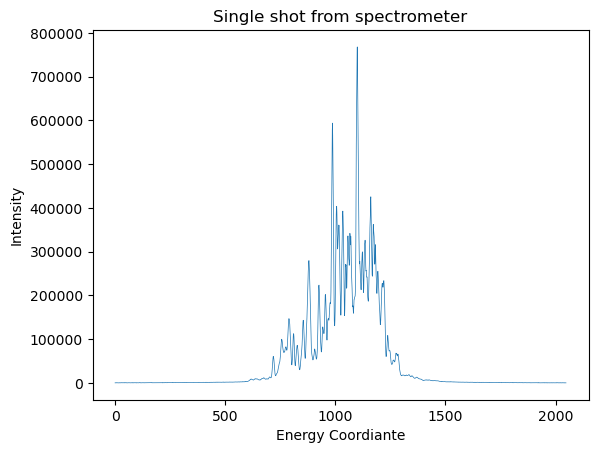

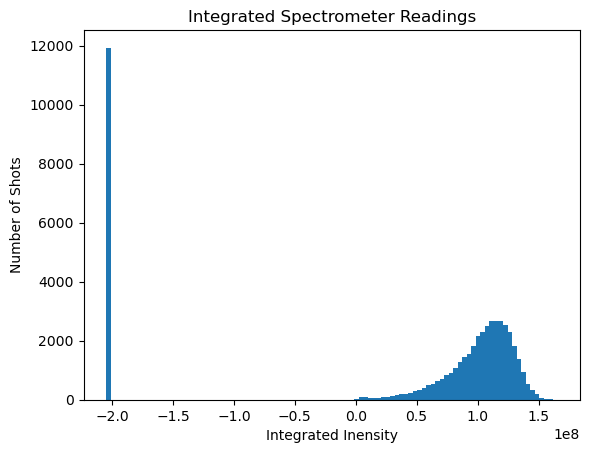

In [5]:
# First filtering out all of the x-ray off shots
specX = spec[xrayOn];
azav0X = azav0[xrayOn];
azav1X = azav1[xrayOn];


# Take a look at one of the lineouts
plt.figure();
plt.plot(specX[1909],linewidth=0.5);
plt.title('Single shot from spectrometer');
plt.xlabel('Energy Coordiante');
plt.ylabel('Intensity');

integratedSpec = np.sum(specX, axis=1);
# And then plot them
plt.figure();
plt.hist(integratedSpec,bins=100); # Plotting the result to see what the average shot to shot looks like
plt.title('Integrated Spectrometer Readings');
plt.xlabel('Integrated Inensity');
plt.ylabel('Number of Shots');

# Show all figures
plt.show()

### As we can see, there are a lot of shots that are bad... this is not good.

<function matplotlib.pyplot.show(close=None, block=None)>

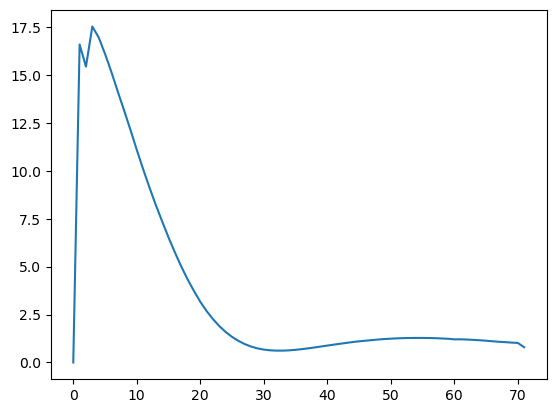

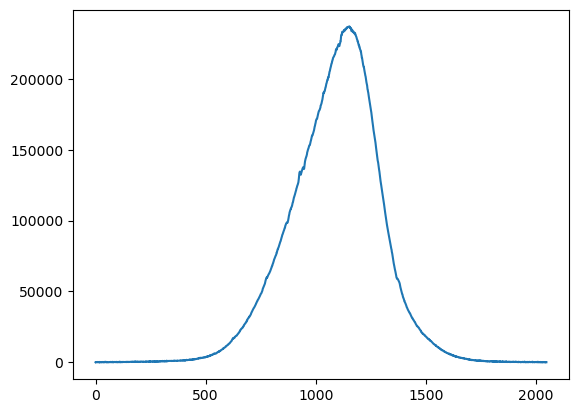

In [6]:
# Figuring out what to remove
goodShots = (integratedSpec>0.25*10**8); # Getting the index of all the low intensity stuff from the spectrometer
specGood = specX[goodShots];
intSpecGood = integratedSpec[goodShots];
azav1Good = azav1X[goodShots];

plt.figure()
plt.plot(np.mean(azav1Good,axis=0))
plt.figure()
plt.plot(np.mean(specGood,axis=0))
plt.show

### So it'd be good if we could cut off some of these arrays to make it easier

<function matplotlib.pyplot.show(close=None, block=None)>

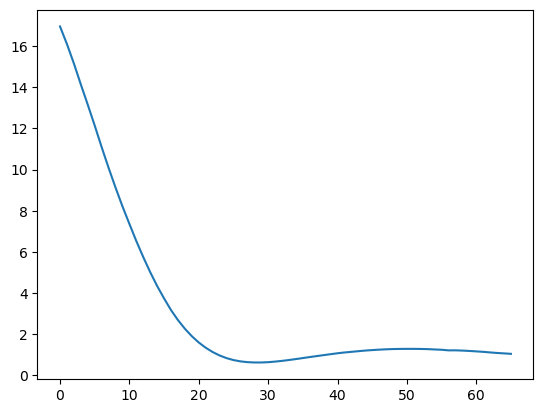

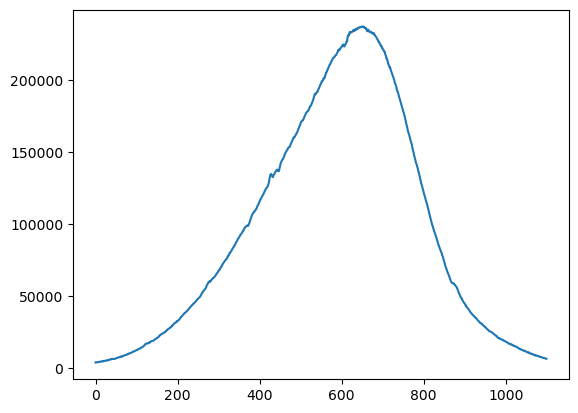

In [7]:
specGood2 = specGood[:,500:1600]; # Cutting off spectrometer values
azav1Good2 = azav1Good[:,4:-2]; # Cutting off q

plt.figure()
plt.plot(np.mean(azav1Good2,axis=0))
plt.figure()
plt.plot(np.mean(specGood2,axis=0))
plt.show

### That's looking better, now let's look at their correlation

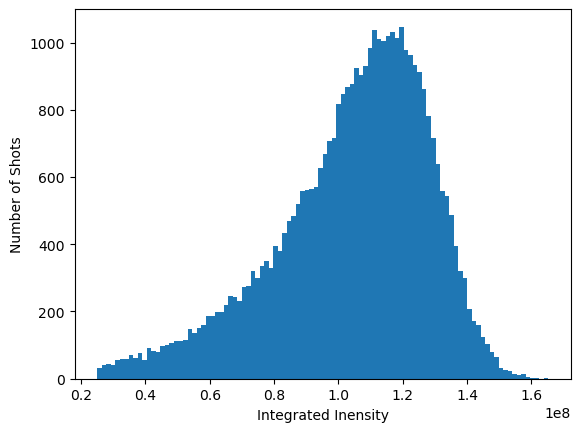

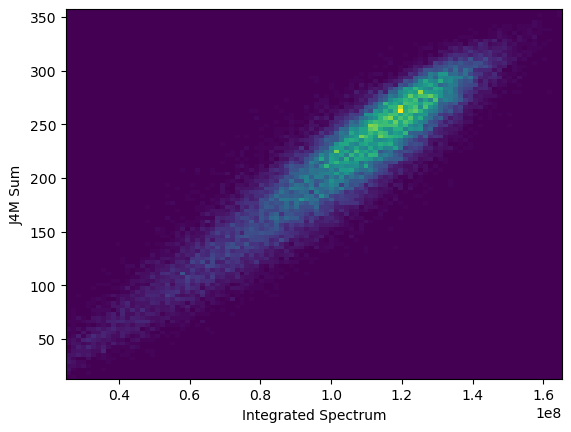

In [8]:
totScattGood = np.sum(azav1Good2, axis=1); # Total scattering signal on the shot to shot basis
integratedSpec = np.sum(specGood2, axis=1); # Recalculating this so that it only includes the range we are interested in

# Plotting
plt.figure();
plt.hist(intSpecGood,bins=100);
plt.xlabel('Integrated Inensity');
plt.ylabel('Number of Shots');
plt.figure();
counts, xedges, yedges, im = plt.hist2d(intSpecGood,totScattGood,100); # <- What the heck???
plt.xlabel('Integrated Spectrum');
plt.ylabel('J4M Sum');

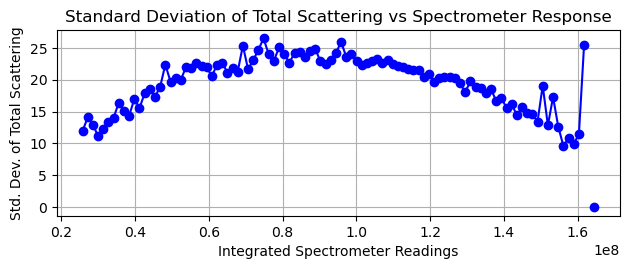

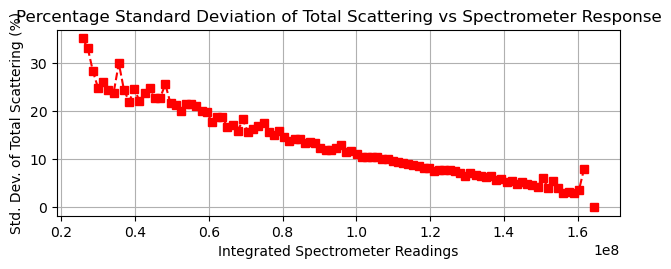

In [9]:
# Define the number of bins
num_bins = 100

# Bin the data based on integratedSpecCorrected
bin_edges = np.linspace(np.min(intSpecGood), np.max(intSpecGood), num_bins + 1)
bin_centers = 0.5 * (bin_edges[:-1] + bin_edges[1:])

# Initialize array to hold standard deviations
std_totScatt = np.zeros(num_bins)
mean_totScatt = np.zeros(num_bins)

# Compute standard deviation for each bin
for i in range(num_bins):
    # Get indices of data points in the current bin
    bin_indices = (intSpecGood >= bin_edges[i]) & (intSpecGood < bin_edges[i + 1])
    # Compute standard deviation of totScattGood for the current bin
    std_totScatt[i] = np.std(totScattGood[bin_indices]) if np.any(bin_indices) else np.nan
    mean_totScatt[i] = np.mean(totScattGood[bin_indices]) if np.any(bin_indices) else np.nan

# Calculate percentage representation of standard deviation
percentage_std = (std_totScatt / mean_totScatt) * 100

# Plot the standard deviation as a function of spectrometer response
plt.subplot(2, 1, 1)
plt.plot(bin_centers, std_totScatt, marker='o', linestyle='-', color='b')
plt.xlabel('Integrated Spectrometer Readings')
plt.ylabel('Std. Dev. of Total Scattering')
plt.title('Standard Deviation of Total Scattering vs Spectrometer Response')
plt.grid(True)
plt.tight_layout()
plt.show()

# Plot the percentage standard deviation as a function of spectrometer response
plt.subplot(2, 1, 2)
plt.plot(bin_centers, percentage_std, marker='s', linestyle='--', color='r')
plt.xlabel('Integrated Spectrometer Readings')
plt.ylabel('Std. Dev. of Total Scattering (%)')
plt.title('Percentage Standard Deviation of Total Scattering vs Spectrometer Response')
plt.grid(True)
plt.tight_layout()
plt.show()

In [10]:
STDweights = counts.sum(axis=1)
valid = ~np.isnan(std_totScatt)
averageSTD = np.average(std_totScatt[valid], weights=STDweights[valid])
print(averageSTD)
# Finally expressing it as a precentage of the average
avgJitter = (averageSTD/np.average(totScattGood))*100
print(avgJitter)

21.520583571423302
9.915027316512168


## Not great, so let's try to add in the Ghost Imaging Analysis to get a better correlation.

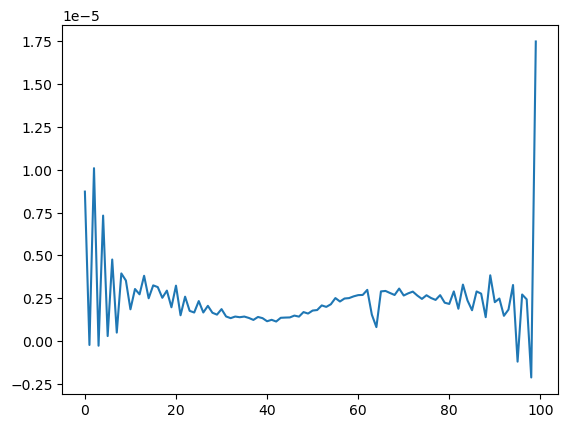

In [11]:
# Re-binning the spectrometer data on a shot-to-shot basis
N=100 # New amount of bins. (original is 1100)

total_shots = specGood2.shape[0];
original_bins = specGood2.shape[1];
if original_bins % N != 0: # See if the new amount of bins are good
    raise ValueError("Number of original bins must be divisible by N.")
delta_N = specGood2.shape[1] // N; # Bin size


# Preallocate the rebinned spectrum
specGoodRebin = np.zeros((total_shots, N))

# Perform the rebinning
for i in range(total_shots):
    for j in range(N):
        sidx = j * delta_N
        eidx = (j + 1) * delta_N
        specGoodRebin[i, j] = np.sum(specGood2[i, sidx:eidx])
F_bright, residuals, rank, s = np.linalg.lstsq(specGoodRebin, totScattGood, rcond=None)
plt.plot(F_bright)

Text(0, 0.5, 'Correction Factor')

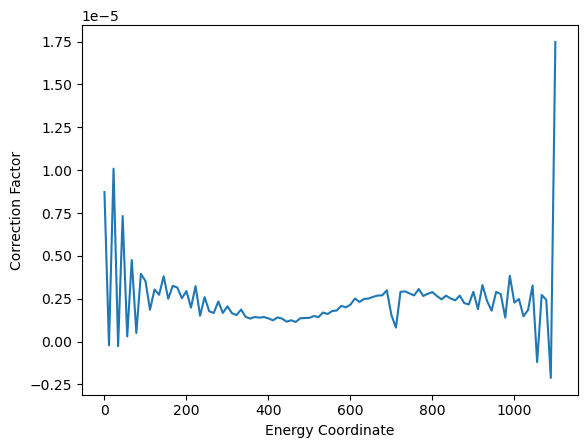

In [12]:
new_bins = np.linspace(0,1100,100)
plt.plot(new_bins,F_bright)
plt.xlabel("Energy Coordinate")
plt.ylabel("Correction Factor")

### Sweet! We can clearly see the absorption edge from the ghist imaging analysis, let's use this to correct the correlations.

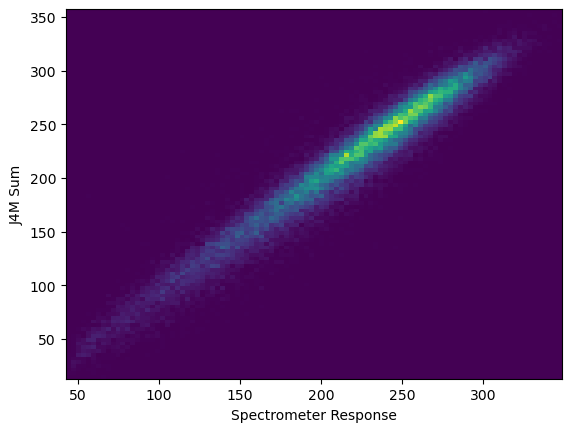

In [13]:
integratedSpecCorrected=np.sum(np.multiply(specGoodRebin,F_bright),axis=1);
plt.figure();
counts, xedges, yedges, im = plt.hist2d(integratedSpecCorrected,totScattGood,100); # The counts variable will be used later.
plt.xlabel('Spectrometer Response');
plt.ylabel('J4M Sum');

## Very nice! We now have a better plot after factoring in the ghost imaging to the spectrum! Woo!

### Now let's do some analysis on what the stdev is with these bins.

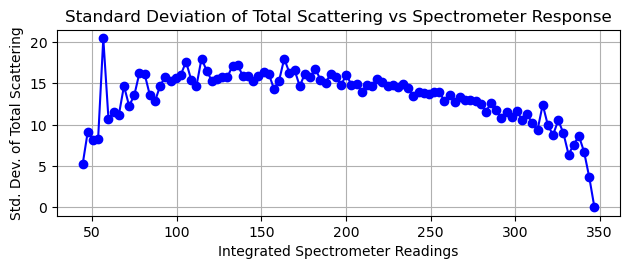

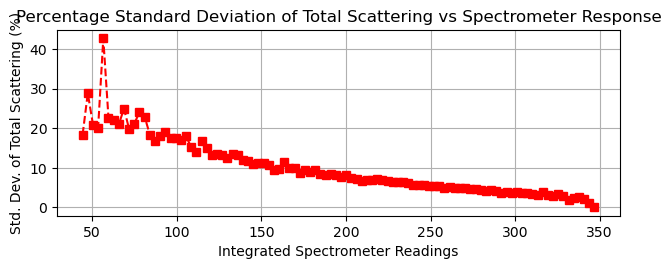

In [14]:
# Define the number of bins
num_bins = 100

# Bin the data based on integratedSpecCorrected
bin_edges = np.linspace(np.min(integratedSpecCorrected), np.max(integratedSpecCorrected), num_bins + 1)
bin_centers = 0.5 * (bin_edges[:-1] + bin_edges[1:])

# Initialize array to hold standard deviations
std_totScattGood = np.zeros(num_bins)
mean_totScattGood = np.zeros(num_bins)

# Compute standard deviation for each bin
for i in range(num_bins):
    # Get indices of data points in the current bin
    bin_indices = (integratedSpecCorrected >= bin_edges[i]) & (integratedSpecCorrected < bin_edges[i + 1])
    # Compute standard deviation of totScattGood for the current bin
    std_totScattGood[i] = np.std(totScattGood[bin_indices]) if np.any(bin_indices) else np.nan
    mean_totScattGood[i] = np.mean(totScattGood[bin_indices]) if np.any(bin_indices) else np.nan

# Calculate percentage representation of standard deviation
percentage_std = (std_totScattGood / mean_totScattGood) * 100

# Plot the standard deviation as a function of spectrometer response
plt.subplot(2, 1, 1)
plt.plot(bin_centers, std_totScattGood, marker='o', linestyle='-', color='b')
plt.xlabel('Integrated Spectrometer Readings')
plt.ylabel('Std. Dev. of Total Scattering')
plt.title('Standard Deviation of Total Scattering vs Spectrometer Response')
plt.grid(True)
plt.tight_layout()
plt.show()

# Plot the percentage standard deviation as a function of spectrometer response
plt.subplot(2, 1, 2)
plt.plot(bin_centers, percentage_std, marker='s', linestyle='--', color='r')
plt.xlabel('Integrated Spectrometer Readings')
plt.ylabel('Std. Dev. of Total Scattering (%)')
plt.title('Percentage Standard Deviation of Total Scattering vs Spectrometer Response')
plt.grid(True)
plt.tight_layout()
plt.show()

In [15]:
# Okay. Let' get the average stdev and express it as a percent of the average spectrometer response.
# So we have an array of standard deviations, let's do a weighted average based on the total number of counts in each time bin.
STDweights = counts.sum(axis=1)
valid = ~np.isnan(std_totScattGood)
averageSTD = np.average(std_totScattGood[valid], weights=STDweights[valid])
print(averageSTD)
# Finally expressing it as a precentage of the average
avgJitter = (averageSTD/np.average(totScattGood))*100
print(avgJitter)
print(total_shots)

14.333685774762666
6.603858372678618
38365


## Cool. Now we have some sample data to do some testing with.

In [19]:
# Let's make the sample data
total_shots = totScattGood.shape[0];
print(total_shots)
S1 = totScattGood;
S2 = np.flip(totScattGood);

I1 = integratedSpecCorrected;
I2 = np.flip(integratedSpecCorrected);

# Perform the linear fit so that we can calculate the magnitude of all necessary coeficients
a, residuals, rank, singular_values = np.linalg.lstsq(I1[:, np.newaxis], S1, rcond=None)
meanI = np.mean(I1); # Mean valye for scaling things
lowT = 0.80;
highT = 0.05;

a1 = a*lowT;
a2 = a1*highT;

b1 = (a1*0.01)/meanI;
b2 = b1*highT;
c = (a1*0.02)/meanI;

# Now to generate the fake data with noise using these coefficients
idx = 0;
perra =  [];
perrb = [];
perrc = [];
for avg in range(0,100):
    errat =  [];
    errbt = [];
    errct = [];
    for noise_level in np.arange(0, 0.25, 0.01):
        
        # Generate the noisy data
        if True:
            S1 = a1 * I1 * (1 + noise_level * np.random.randn(total_shots));
            S2 = a2 * I2 * (1 + noise_level * np.random.randn(total_shots));
        
        S11 = b1 * I1**2 * (1 + noise_level * 2 * np.random.randn(total_shots));
        S22 = b2 * I2**2 * (1 + noise_level * 2 * np.random.randn(total_shots));
        # Generate the cross term (S12)
        S12 = c * I1 * I2 * (1 + noise_level * 2 *  np.random.randn(total_shots));
        
        # Combining everything up together so that we get the total signals
        # NOTE: This is not entirely correct, there should be attenuation due to the metal filter done correctly here.
        
        S_total_filtered = S1+S2+S11+S22+S12;
        #S_total = S1+S2+S11+S22+S12;
        
        
        # Prepare the design matrix
        X = np.column_stack([I1 * I2,I2,I2**2])
        
        # Fit the linear regression model
        model = LinearRegression()
        model.fit(X, S_total_filtered)
        
        # Extract coefficients
        coefficients = model.coef_
        intercept = model.intercept_
        
        # Calculate % errors and append to respective lists
        errat.append((np.abs(coefficients[0] - a1) / a1) * 100)
        errbt.append((np.abs(coefficients[1] - b1) / b1) * 100)
        errct.append((np.abs(coefficients[2] - c) / c) * 100)
    perra.append(errat);
    perrb.append(errbt);
    perrc.append(errct);
    if avg%10==0: print(avg)


38365
0
10
20
30
40
50
60
70
80
90


 ### Now, knowing only S_total_filtered, I1, and I2, we should be able to get back the coefficients.

In [98]:
erra = np.squeeze(np.array(perra));
errb = np.squeeze(np.array(perrb));
errc = np.squeeze(np.array(perrc));

erraAvg = np.mean(erra,axis=0);
errbAvg = np.mean(errb,axis=0);
errcAvg = np.mean(errc,axis=0);

erraSTD = np.std(erra,axis=0);
errbSTD = np.std(errb,axis=0);
errcSTD = np.std(errc,axis=0);
noise_level = np.arange(0, 0.25, 0.01)*100;

# Linear fit for each dataset
fit_a = np.polyfit(noise_level, erraAvg, 1)  # Linear fit (slope, intercept)
fit_b = np.polyfit(noise_level, errbAvg, 1)
fit_c = np.polyfit(noise_level, errcAvg, 1)

# Generate fitted lines for plotting
fit_line_a = np.polyval(fit_a, noise_level)
fit_line_b = np.polyval(fit_b, noise_level)
fit_line_c = np.polyval(fit_c, noise_level)

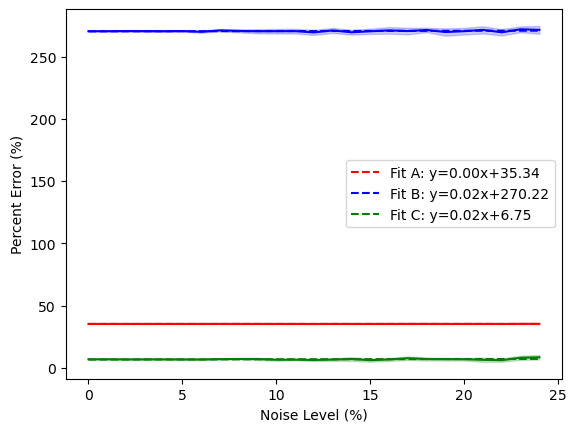

In [99]:
plt.figure()
plt.plot(noise_level,erraAvg,color='r')
plt.fill_between(noise_level,erraAvg-erraSTD,erraAvg+erraSTD, color='r', alpha=0.2)
plt.plot(noise_level,errbAvg,color='b')
plt.fill_between(noise_level,errbAvg-errbSTD,errbAvg+errbSTD, color='b', alpha=0.2)
plt.plot(noise_level,errcAvg,color='g')
plt.fill_between(noise_level,errcAvg-errcSTD,errcAvg+errcSTD, color='g', alpha=0.2)

# Plot fitted lines
plt.plot(noise_level, fit_line_a, 'r--', label=f'Fit A: y={fit_a[0]:.2f}x+{fit_a[1]:.2f}')
plt.plot(noise_level, fit_line_b, 'b--', label=f'Fit B: y={fit_b[0]:.2f}x+{fit_b[1]:.2f}')
plt.plot(noise_level, fit_line_c, 'g--', label=f'Fit C: y={fit_c[0]:.2f}x+{fit_c[1]:.2f}')

plt.ylabel('Percent Error (%)')
plt.xlabel('Noise Level (%)')
plt.legend()
plt.show()
